In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D,MaxPooling2D,Dropout,Flatten,Dense)

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv("fashion-mnist_test.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.isnull().sum()

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64

In [5]:
X = df.drop("label", axis=1).values
y = df["label"].values

In [6]:
X = X / 255.0

In [7]:
X = X.reshape(-1, 28, 28, 1)

In [8]:
y = to_categorical(y) 

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
model = Sequential()

In [11]:
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))


C:\Users\hetal\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.add(MaxPooling2D((2,2)))

In [13]:
model.add(Dropout(0.25))

In [14]:
model.add(Conv2D(64,(3,3),activation='relu'))

In [15]:
model.add(MaxPooling2D((2,2)))


model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

In [16]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [17]:
history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5806 - loss: 1.1247 - val_accuracy: 0.7506 - val_loss: 0.6572
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7336 - loss: 0.7006 - val_accuracy: 0.7881 - val_loss: 0.5536
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7669 - loss: 0.6091 - val_accuracy: 0.7994 - val_loss: 0.5327
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7872 - loss: 0.5605 - val_accuracy: 0.8106 - val_loss: 0.5058
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8037 - loss: 0.5277 - val_accuracy: 0.8338 - val_loss: 0.4682
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8123 - loss: 0.5080 - val_accuracy: 0.8369 - val_loss: 0.4519
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8188 - loss: 0.4717 - val_accuracy: 0.8506 - val_loss: 0.4216
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8280 - loss: 0.4576 - val_accurac

In [18]:
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8590 - loss: 0.3963

Test Accuracy: 0.859000027179718


In [19]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [20]:
print("\nClassification Report:\n")

print(classification_report(true_classes,predicted_classes))


Classification Report:



              precision    recall  f1-score   support

           0       0.73      0.84      0.78       192
           1       0.98      0.96      0.97       192
           2       0.74      0.83      0.78       212
           3       0.85      0.92      0.89       205
           4       0.77      0.78      0.77       204
           5       0.96      0.99      0.98       193
           6       0.69      0.46      0.55       200
           7       0.91      0.95      0.93       206
           8       0.98      0.96      0.97       196
           9       0.97      0.91      0.94       200

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



In [21]:
cm = confusion_matrix(true_classes,predicted_classes)
print("\nConfusion Matrix:\n")
print(cm)


Confusion Matrix:

[[161   0   4  15   0   0  11   0   1   0]
 [  0 185   0   7   0   0   0   0   0   0]
 [  4   0 175   0  22   0  10   0   1   0]
 [  5   2   2 189   5   0   2   0   0   0]
 [  0   0  25   4 159   0  16   0   0   0]
 [  0   0   0   0   0 191   0   1   1   0]
 [ 51   1  29   7  20   0  92   0   0   0]
 [  0   0   0   0   0   5   0 195   0   6]
 [  0   0   1   0   1   0   3   2 189   0]
 [  0   0   0   0   0   2   0  16   0 182]]


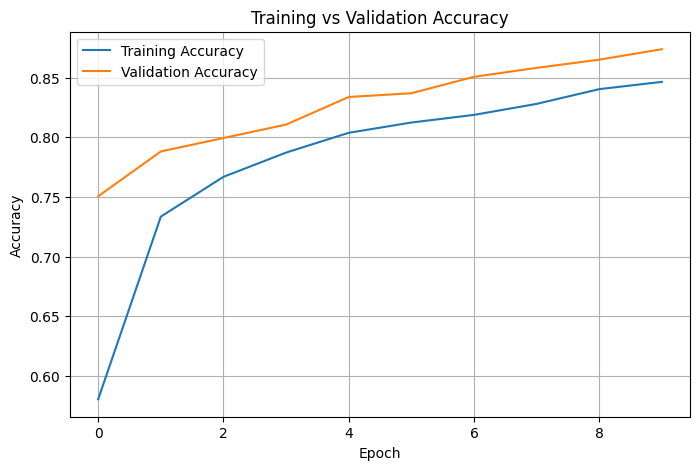

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')

plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()